In [274]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
recipes_df = pd.read_csv("./data/recipes.csv")

In [275]:

def Gettransitionmodel(recipes_df):
    result = {}

    for _, row in recipes_df.iterrows():
        meal_type = row["type"]
        meal_name = row["Name"]

        meal_info = (
            row["Category"],
            row["total_price"],
            row["provided_calories"],
            row["provided_protein"],
            row["provided_carbs"],
            row["provided_fat"]
        )
        if meal_type not in result:
           result[meal_type] = {}

        result[meal_type][meal_name] = meal_info

    return result


In [276]:
NUTRI_PREFERENCE_MAP = {
    "maintain":       {"protein": 0.30, "fat": 0.25, "carbs": 0.45},
    "gain":   {"protein": 0.40, "fat": 0.25, "carbs": 0.35},
    "loss":       {"protein": 0.25, "fat": 0.35, "carbs": 0.40},
}

In [277]:

def resolve_nutri_preference(preference_str):
    key = preference_str.strip().lower()
    if key not in NUTRI_PREFERENCE_MAP:
        valid = ", ".join(NUTRI_PREFERENCE_MAP.keys())
        raise ValueError(f"Unknown preference '{preference_str}'. Valid options: {valid}")
    return NUTRI_PREFERENCE_MAP[key]

In [278]:
def diversity_penalty_per_week(state):
    penalty = 0
    days_per_week = 7
    meals_per_day = 3

    for start in range(0, len(state), days_per_week):
        week = state[start:start + days_per_week]

        week_meals = [meal for day in week for meal in day]

        counts = {}
        for meal in week_meals:
            counts[meal] = counts.get(meal, 0) + 1

        for meal, count in counts.items():
            if count > 2:
                penalty += (count - 2)
    return penalty / (len(state) * meals_per_day)

In [279]:

class GAProblem:
    def __init__(self, recipes_df, total_price, tdee, nutri_preference_str="maintain"):
        self.size = 90 # we did not use this at all occurance = 1
        self.total_price = total_price
        self.tdee = tdee
        self.transitionmodel = Gettransitionmodel(recipes_df)
        prefs = resolve_nutri_preference(nutri_preference_str)
        self.target_protein_g = tdee * prefs["protein"]
        self.target_fat_g     = tdee * prefs["fat"]
        self.target_carbs_g   = tdee * prefs["carbs"]
     
     
    def get_total_cost(self, state):
        total_cost = 0
        for i in range(len(state)):
           breakfast_cost =  self.transitionmodel["Breakfast"][state[i][0]][1]
           lunch_cost = self.transitionmodel["Lunch"][state[i][1]][1]
           dinner_cost  = self.transitionmodel["Dinner"][state[i][2]][1]
           day_cost = breakfast_cost+lunch_cost+dinner_cost
           total_cost += day_cost
        return total_cost
    
    
    def get_total_cal(self,state):
        day_calories = []
        for day in state:
            day_cal = (
            self.transitionmodel["Breakfast"][day[0]][2] +
            self.transitionmodel["Lunch"][day[1]][2] +
            self.transitionmodel["Dinner"][day[2]][2]
        )
            if day_cal > self.tdee * 1.1 or day_cal < self.tdee * 0.9:
                print(day_cal)
                print("Out of calories range")
            day_calories.append(day_cal)
        
        return sum(day_calories)
    

    def _macro_penalty_for_day(self, day):
        actual_protein =  self.transitionmodel["Breakfast"][day[0]][3] +  self.transitionmodel["Dinner"][day[2]][3] +  self.transitionmodel["Lunch"][day[1]][3]
        actual_carbs   = self.transitionmodel["Breakfast"][day[0]][4] +  self.transitionmodel["Dinner"][day[2]][4] +  self.transitionmodel["Lunch"][day[1]][4]
        actual_fat   = self.transitionmodel["Breakfast"][day[0]][5] +  self.transitionmodel["Dinner"][day[2]][5] +  self.transitionmodel["Lunch"][day[1]][5]  
        protein_dev = abs(actual_protein - self.target_protein_g) / self.target_protein_g
        fat_dev     = abs(actual_fat     - self.target_fat_g)     / self.target_fat_g
        carbs_dev   = abs(actual_carbs   - self.target_carbs_g)   / self.target_carbs_g
        return (protein_dev + fat_dev + carbs_dev) / 3
    

    def fitness_function(self, state):
        total_cost = self.get_total_cost(state)
        cost_penalty = 1 if (self.total_price - total_cost) / (self.total_price) < 0 else (self.total_price - total_cost) / (self.total_price)
        lower_bound = 0.9 * self.tdee
        upper_bound = 1.1 * self.tdee

        bad_days = 0
        total_macro_dev=0
        for day in state:
            day_calories = (
                self.transitionmodel["Breakfast"][day[0]][2] +
                self.transitionmodel["Lunch"][day[1]][2] +
                self.transitionmodel["Dinner"][day[2]][2]
            )
            if day_calories != self.tdee:
                bad_days += 0.001
            if day_calories < lower_bound or day_calories > upper_bound:
                bad_days += 1
            total_macro_dev += self._macro_penalty_for_day(day)
        nutrition_penalty = bad_days / len(state)
        macro_penalty     = total_macro_dev / len(state)
        diversity_penalty = diversity_penalty_per_week(state)
        fitness = -(
            0.3 * cost_penalty +
            0.2* nutrition_penalty +
            0.15 * diversity_penalty +
            0.35* macro_penalty
        )
        return fitness
    
    
    def generate_random_state(self):
         breakfast_list = list(self.transitionmodel['Breakfast'].keys())
         lunch_list = list(self.transitionmodel['Lunch'].keys())
         dinner_list = list(self.transitionmodel['Dinner'].keys())
         return [(random.choice(breakfast_list),
                  random.choice(lunch_list),
                  random.choice(dinner_list))
                    for _ in range(30)]


In [280]:
def crossover_and_mutation(population,problem):
       childs = []
     
       for i in range(len(population)):
         for j in range(i+1,len(population)):
            cutoff = random.randrange(1,29)
            parent_a = population[i][0]
            parent_b = population[j][0]
            child_a = parent_a[:cutoff] + parent_b[cutoff:]
            child_b = parent_b[:cutoff] + parent_a[cutoff:]
            random_lunch_a = random.choice(list(problem.transitionmodel['Lunch'].keys()))
            random_lunch_b = random.choice(list(problem.transitionmodel['Lunch'].keys()))
            random_pos_a  = random.randrange(30)
            random_pos_b  = random.randrange(30)
            t1 =   [child_a[random_pos_a][0],random_lunch_a, child_a[random_pos_a][2]]
            t2 =  [child_b[random_pos_b][0],random_lunch_b, child_b[random_pos_b][2]]
            child_a[random_pos_a] = tuple(t1) 
            child_b[random_pos_b] = tuple(t2) 
            childs.append((child_a,problem.fitness_function(child_a)))
            childs.append((child_b,problem.fitness_function(child_b)))
       return childs



In [281]:

def GASearch(problem):
    # step 1 Selection:
    list_of_states = []
    for _ in range(100):
        state = problem.generate_random_state()
        fitness = problem.fitness_function(state)
        list_of_states.append((state,fitness))
    population = sorted(list_of_states, key=lambda x: x[1], reverse=True)[:25]
    # step 2 and 3 crossover and mutation
    for _ in range(250):
        population = sorted(population, key=lambda x: x[1], reverse=True)[:25]
        for state, fitness in population:
            if fitness == 0:
                return (state, fitness)
        population =  crossover_and_mutation(population,problem)
    best_candidate = sorted(population, key=lambda x: x[1], reverse=True)[:1]
    return best_candidate[0]

In [ ]:
g = GAProblem(recipes_df,30000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(g.get_total_cost(solution))
print(g.get_total_cal(solution))

[('Coffee Date Almond Snack Bowl', 'Egg Fried Rice (GF)', 'Beef Spinach Garlic Pan'), ('Breakfast Omelette', 'Shrimp Avocado Salad', 'Tuna Vegetable Couscous Dinner'), ('Beef Egg Breakfast Bowl', 'Lentil Beef Bowl', 'Green Bean Rice Bowl'), ('Yogurt Fig Honey Bowl', 'Loubia Chicken Plate', 'Dolma'), ('Bourek', 'Shrimp Rice Bowl', 'Beef Loubia Stew'), ('Fruit Salad', 'Lentil Beef Bowl', 'Shrimp Chickpea Harissa Dinner'), ('Banana Peanut Protein Smoothie', 'Shrimp Rice Bowl', 'Mutton Carrot Pea Dinner'), ('Tuna Olive Breakfast Salad', 'Lentil Beef Bowl', 'Green Bean Rice Bowl'), ('Lentil Egg Breakfast Bowl', 'Tuna Chickpea Mint Salad', 'Beef Loubia Stew'), ('Gluten-Free Omelette', 'Tajine Zitoun', 'Zucchini Tomato Couscous'), ('Carrot Raisin Yogurt Bowl', 'Couscous Merlan Mint', 'Lham Bel Barba'), ('Potato Omelette', 'Egg Fried Rice (GF)', 'Daurade Zucchini Olive Dinner'), ('Carrot Raisin Yogurt Bowl', 'Lentil Beef Bowl', 'Chorba Vermicelle Beef'), ('Protein Yogurt Crunch', 'Shrimp Avoca

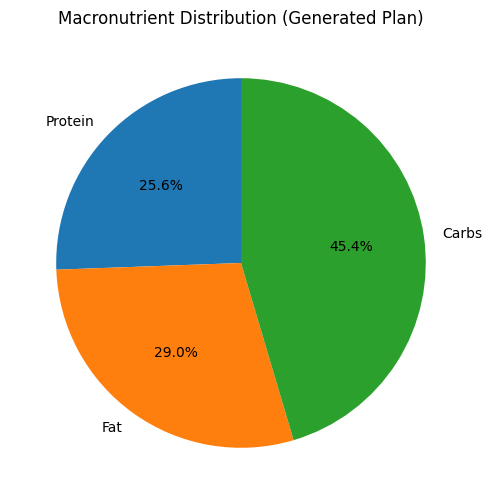

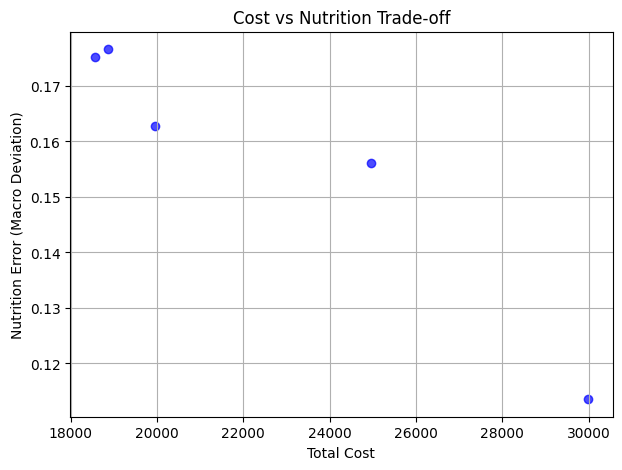

In [283]:

def get_macro_nutrition(transitionmodel, state): # we have two of this one for visulaization and one for the fitness 
    protein_v = 0
    fat_v = 0
    carbs_v = 0
    total_cal = 0
    for day in state:
        total_cal += transitionmodel["Breakfast"][day[0]][2] + transitionmodel["Lunch"][day[1]][2] + transitionmodel["Dinner"][day[2]][2]
        protein_v += transitionmodel["Breakfast"][day[0]][3] + transitionmodel["Lunch"][day[1]][3] + transitionmodel["Dinner"][day[2]][3]
        fat_v     +=transitionmodel["Breakfast"][day[0]][5] + transitionmodel["Lunch"][day[1]][5] + transitionmodel["Dinner"][day[2]][5]
        carbs_v   += transitionmodel["Breakfast"][day[0]][4] + transitionmodel["Lunch"][day[1]][4] + transitionmodel["Dinner"][day[2]][4]
    return [protein_v / total_cal, fat_v / total_cal, carbs_v / total_cal]

def macro_error(meals,state): # we have two also in this we use it in the visualization,fitness,greedy,A*
    macros = get_macro_nutrition(meals,state)

    target = [0.25, 0.35, 0.4]  # example , we can take it from the problem formulation

    error = sum(abs(macros[i] - target[i]) for i in range(3))

    return error

def get_axis_plot(meals):
     costs = []
     errors = []
     i = 10000
     for _ in range(5):  # 30 different solution
        g = GAProblem(recipes_df,i,2000)
        solution,_ = GASearch(g)
        cost = g.get_total_cost(solution)
        error = macro_error(meals,solution)
        i += 5000 
        costs.append(cost)
        errors.append(error)
     return costs,errors

meals_details = Gettransitionmodel(recipes_df) # we caluclate for each prblem except the CSP
labels = ['Protein', 'Fat', 'Carbs']
values = get_macro_nutrition(meals_details,solution)
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (Generated Plan)')
plt.show()
x_axis,y_axis = get_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off")
plt.grid(True)
plt.show()
